<a href="https://colab.research.google.com/github/jeevithajeevitha3420-create/career-campass/blob/main/DreamForge_%E2%80%94_AI_Room_Designer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import pathlib
import os
import matplotlib.pyplot as plt

# Download dataset
_URL = "http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz"

path = tf.keras.utils.get_file(
    fname="facades.tar.gz",
    origin=_URL,
    extract=True
)

# Find the actual facades folder
base_path = pathlib.Path(path).parent

print("Dataset files:")
for item in base_path.iterdir():
    print(item)

# The extracted folder is:
PATH = base_path / "facades_extracted" / "facades"

print("\nDataset path:", PATH)
print("Exists:", PATH.exists())


Dataset files:
/root/.keras/datasets/facades.tar.gz
/root/.keras/datasets/facades_extracted

Dataset path: /root/.keras/datasets/facades_extracted/facades
Exists: True


In [ ]:
train_path = PATH / "train"

image_extensions = ["*.jpg", "*.jpeg", "*.png"]

train_images = []

for extension in image_extensions:
    train_images.extend(train_path.glob(extension))

print("Training images:", len(train_images))

if len(train_images) == 0:
    print("\nNo images found.")
    print("Files/folders inside train:")
    for item in list(train_path.iterdir())[:20]:
        print(item)

Training images: 400


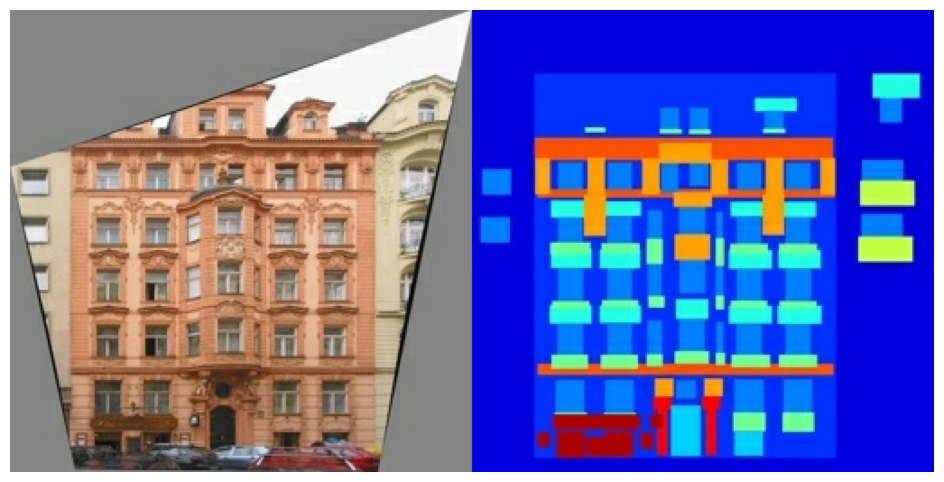

In [ ]:
if len(train_images) > 0:
    image = tf.io.read_file(str(train_images[0]))
    image = tf.image.decode_image(image, channels=3)

    plt.figure(figsize=(12, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("No training images found.")

In [ ]:
IMG_SIZE = 256
BATCH_SIZE = 1

def load_image(file_path):

    image = tf.io.read_file(file_path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.cast(image, tf.float32)

    # Resize paired image
    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    # Normalize 0–255 → -1–1
    image = (image / 127.5) - 1

    # Split into two halves
    width = tf.shape(image)[1]

    input_image = image[:, :width // 2, :]
    target_image = image[:, width // 2:, :]

    return input_image, target_image


train_dataset = tf.data.Dataset.from_tensor_slices(
    [str(x) for x in train_images]
)

train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.batch(BATCH_SIZE)

print("Dataset created!")

Dataset created!


In [ ]:
for input_image, target_image in train_dataset.take(1):

    print("Input shape:", input_image.shape)
    print("Target shape:", target_image.shape)

Input shape: (1, 256, 128, 3)
Target shape: (1, 256, 128, 3)


In [ ]:
from tensorflow.keras import layers

def downsample(filters, size, apply_batchnorm=True):

    initializer = tf.random_normal_initializer(0., 0.02)

    result = tf.keras.Sequential()

    result.add(
        layers.Conv2D(
            filters,
            size,
            strides=2,
            padding="same",
            kernel_initializer=initializer,
            use_bias=False
        )
    )

    if apply_batchnorm:
        result.add(layers.BatchNormalization())

    result.add(layers.LeakyReLU())

    return result


def build_generator():

    inputs = layers.Input(
        shape=[256, 128, 3]
    )

    x = downsample(64, 4, False)(inputs)
    x = downsample(128, 4)(x)
    x = downsample(256, 4)(x)

    x = layers.Conv2DTranspose(
        128,
        4,
        strides=2,
        padding="same"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(
        64,
        4,
        strides=2,
        padding="same"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(
        3,
        4,
        strides=2,
        padding="same",
        activation="tanh"
    )(x)

    return tf.keras.Model(inputs, x)


generator = build_generator()

generator.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 64, 64)    │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 64, 32, 128)    │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 32, 16, 256)    │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 64, 32, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 128, 64, 64)    │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 64, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128, 64, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 256, 128, 3)    │         3,075 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,319,363 (5.03 MB)

 Trainable params: 1,318,211 (5.03 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
for input_image, target_image in train_dataset.take(1):

    generated_image = generator(
        input_image,
        training=False
    )

    print("Input:", input_image.shape)
    print("Generated:", generated_image.shape)
    print("Target:", target_image.shape)

Input: (1, 256, 128, 3)
Generated: (1, 256, 128, 3)
Target: (1, 256, 128, 3)


In [ ]:
def build_discriminator():

    inp = layers.Input(
        shape=[256, 128, 3],
        name="input_image"
    )

    tar = layers.Input(
        shape=[256, 128, 3],
        name="target_image"
    )

    # Combine input + target
    x = layers.concatenate([inp, tar])

    # Downsampling
    x = downsample(64, 4, False)(x)
    x = downsample(128, 4)(x)
    x = downsample(256, 4)(x)

    # Final layers
    x = layers.ZeroPadding2D()(x)

    x = layers.Conv2D(
        512,
        4,
        strides=1,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.ZeroPadding2D()(x)

    output = layers.Conv2D(
        1,
        4,
        strides=1,
        padding="same"
    )(x)

    return tf.keras.Model(
        [inp, tar],
        output
    )


discriminator = build_discriminator()

discriminator.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 256, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ target_image        │ (None, 256, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 128,  │          0 │ input_image[0][0… │
│ (Concatenate)       │ 6)                │            │ target_image[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 128, 64,   │      6,144 │ concatenate[0][0] │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 64, 32,    │    131,584 │ sequential_3[0][… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 32, 16,    │    525,312 │ sequential_4[0][… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 34, 18,    │          0 │ sequential_5[0][… │
│ (ZeroPadding2D)     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 34, 18,    │  2,097,152 │ zero_padding2d[0… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 34, 18,    │      2,048 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 34, 18,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 36, 20,    │          0 │ leaky_re_lu_6[0]… │
│ (ZeroPadding2D)     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 36, 20, 1) │      8,193 │ zero_padding2d_1… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,770,433 (10.57 MB)

 Trainable params: 2,768,641 (10.56 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
for input_image, target_image in train_dataset.take(1):

    generated_image = generator(
        input_image,
        training=False
    )

    real_output = discriminator(
        [input_image, target_image],
        training=False
    )

    fake_output = discriminator(
        [input_image, generated_image],
        training=False
    )

    print("Real output shape:", real_output.shape)
    print("Fake output shape:", fake_output.shape)

Real output shape: (1, 36, 20, 1)
Fake output shape: (1, 36, 20, 1)


In [ ]:
loss_object = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)


def generator_loss(disc_generated_output, gen_output, target):

    # GAN loss
    gan_loss = loss_object(
        tf.ones_like(disc_generated_output),
        disc_generated_output
    )

    # Difference between generated and real image
    l1_loss = tf.reduce_mean(
        tf.abs(target - gen_output)
    )

    # Total Generator loss
    total_loss = gan_loss + (100 * l1_loss)

    return total_loss


def discriminator_loss(
    disc_real_output,
    disc_generated_output
):

    real_loss = loss_object(
        tf.ones_like(disc_real_output),
        disc_real_output
    )

    generated_loss = loss_object(
        tf.zeros_like(disc_generated_output),
        disc_generated_output
    )

    total_loss = real_loss + generated_loss

    return total_loss


print("Loss functions created successfully!")

Loss functions created successfully!


In [ ]:
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

print("Optimizers created successfully!")

Optimizers created successfully!


In [ ]:
@tf.function
def train_step(input_image, target_image):

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        # Generate fake image
        generated_image = generator(
            input_image,
            training=True
        )

        # Discriminator checks real image
        disc_real_output = discriminator(
            [input_image, target_image],
            training=True
        )

        # Discriminator checks fake image
        disc_generated_output = discriminator(
            [input_image, generated_image],
            training=True
        )

        # Calculate losses
        gen_loss = generator_loss(
            disc_generated_output,
            generated_image,
            target_image
        )

        disc_loss = discriminator_loss(
            disc_real_output,
            disc_generated_output
        )

    # Generator gradients
    generator_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    # Discriminator gradients
    discriminator_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # Update Generator
    generator_optimizer.apply_gradients(
        zip(
            generator_gradients,
            generator.trainable_variables
        )
    )

    # Update Discriminator
    discriminator_optimizer.apply_gradients(
        zip(
            discriminator_gradients,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss


print("Training function created successfully!")

Training function created successfully!


In [ ]:
for input_image, target_image in train_dataset.take(1):

    gen_loss, disc_loss = train_step(
        input_image,
        target_image
    )

    print("Generator loss:", float(gen_loss))
    print("Discriminator loss:", float(disc_loss))

Generator loss: 75.94923400878906
Discriminator loss: 1.65969979763031


In [ ]:
EPOCHS = 3

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    gen_loss_total = 0.0
    disc_loss_total = 0.0
    batches = 0

    for input_image, target_image in train_dataset:

        gen_loss, disc_loss = train_step(
            input_image,
            target_image
        )

        gen_loss_total += float(gen_loss)
        disc_loss_total += float(disc_loss)
        batches += 1

    print(
        f"Generator Loss: {gen_loss_total / batches:.4f}"
    )

    print(
        f"Discriminator Loss: {disc_loss_total / batches:.4f}"
    )



Epoch 1/3
Generator Loss: 45.1949
Discriminator Loss: 0.5707

Epoch 2/3
Generator Loss: 41.7416
Discriminator Loss: 0.5247

Epoch 3/3
Generator Loss: 40.8298
Discriminator Loss: 0.5106


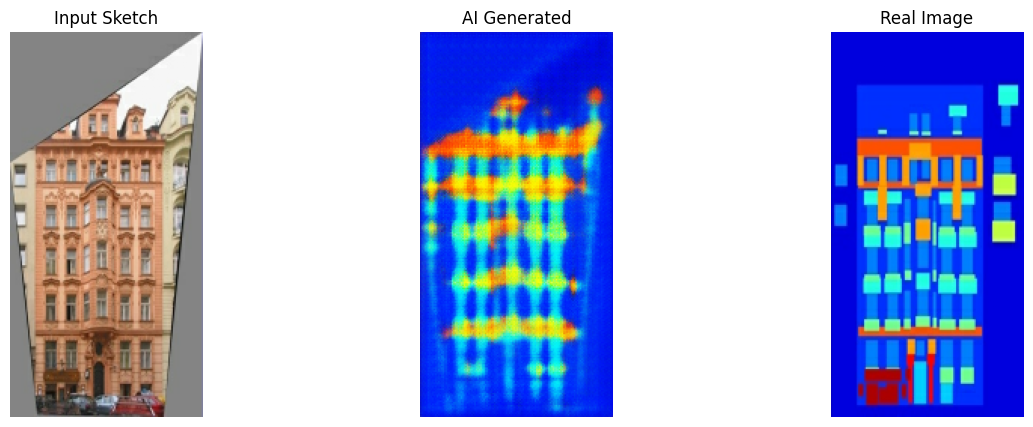

In [ ]:
for input_image, target_image in train_dataset.take(1):

    # Generate image
    generated_image = generator(
        input_image,
        training=False
    )

    plt.figure(figsize=(15, 5))

    # Input
    plt.subplot(1, 3, 1)
    plt.imshow((input_image[0] + 1) / 2)
    plt.title("Input Sketch")
    plt.axis("off")

    # Generated
    plt.subplot(1, 3, 2)
    plt.imshow((generated_image[0] + 1) / 2)
    plt.title("AI Generated")
    plt.axis("off")

    # Real
    plt.subplot(1, 3, 3)
    plt.imshow((target_image[0] + 1) / 2)
    plt.title("Real Image")
    plt.axis("off")

    plt.show()

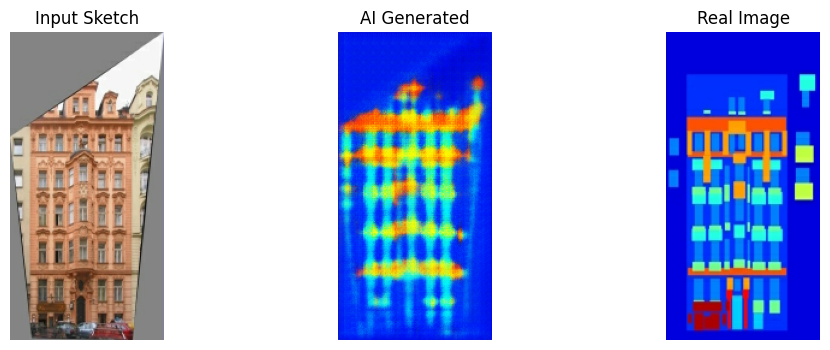

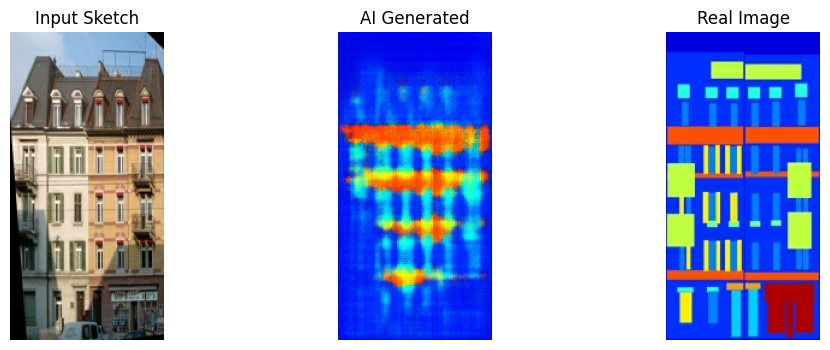

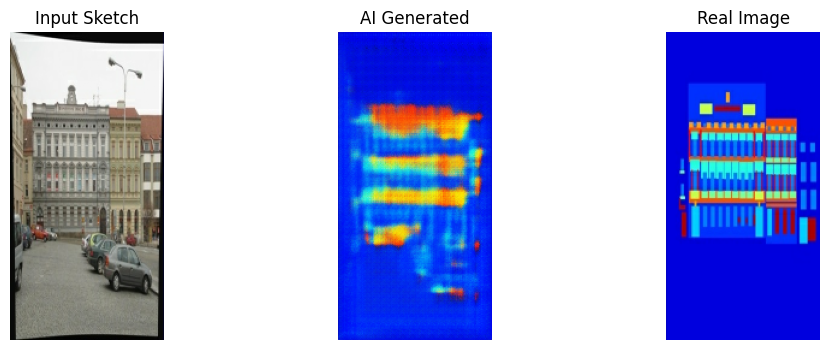

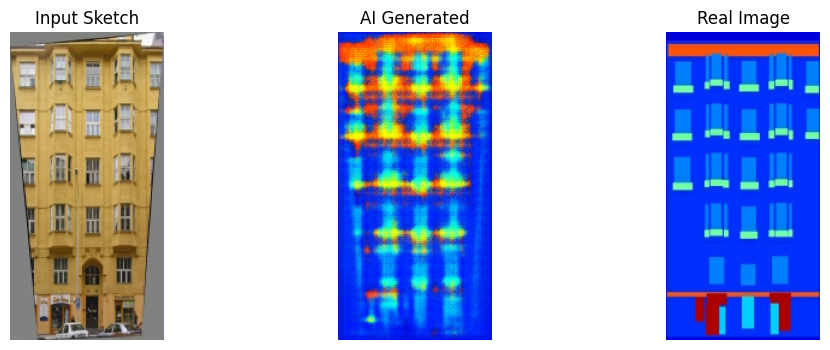

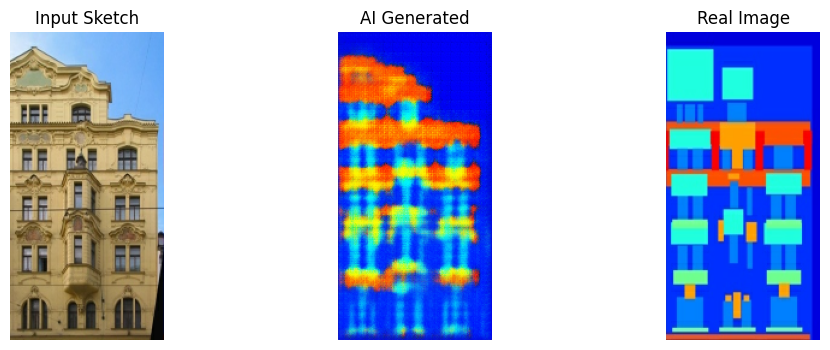

In [ ]:
import matplotlib.pyplot as plt

count = 0

for input_image, target_image in train_dataset:

    generated_image = generator(
        input_image,
        training=False
    )

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow((input_image[0] + 1) / 2)
    plt.title("Input Sketch")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow((generated_image[0] + 1) / 2)
    plt.title("AI Generated")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow((target_image[0] + 1) / 2)
    plt.title("Real Image")
    plt.axis("off")

    plt.show()

    count += 1

    if count == 5:
        break

In [ ]:
generator.save("/content/dreamforge_generator.keras")

print("DreamForge model saved! ✅")


DreamForge model saved! ✅


In [ ]:
import os

print(os.path.exists("/content/dreamforge_generator.keras"))


True


Saving photo to photo


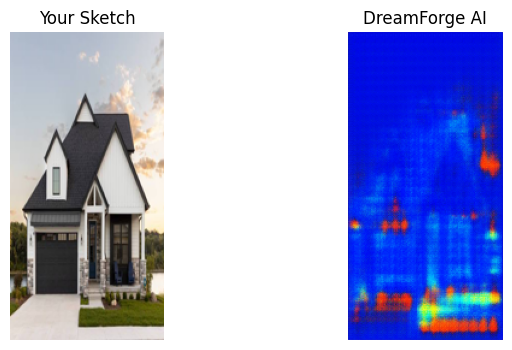

In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

uploaded = files.upload()

filename = list(uploaded.keys())[0]

image = Image.open(filename).convert("RGB")

# Resize to the size expected by our model
image = image.resize((128, 256))

# Convert to NumPy
image = np.array(image).astype(np.float32)

# Normalize
image = (image / 127.5) - 1

# Add batch dimension
input_image = tf.expand_dims(image, 0)

# Generate image
generated_image = generator(
    input_image,
    training=False
)

# Display
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow((input_image[0] + 1) / 2)
plt.title("Your Sketch")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow((generated_image[0] + 1) / 2)
plt.title("DreamForge AI")
plt.axis("off")

plt.show()

In [ ]:
print("Current model:")
print("Input  : Building Sketch")
print("Output : Building Image")
print()
print("DreamForge goal:")
print("Input  : Room Sketch")
print("Output : Room Interior")

Current model:
Input  : Building Sketch
Output : Building Image

DreamForge goal:
Input  : Room Sketch
Output : Room Interior


In [ ]:
import os

os.makedirs("/content/room_dataset/train", exist_ok=True)
os.makedirs("/content/room_dataset/test", exist_ok=True)

print("Room dataset folders created! ✅")

Room dataset folders created! ✅


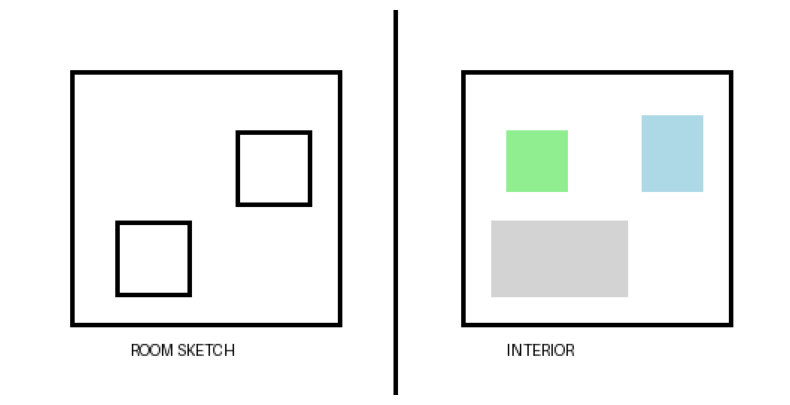

First room image created! ✅


In [ ]:
from PIL import Image, ImageDraw

# Create canvas
img = Image.new("RGB", (512, 256), "white")
draw = ImageDraw.Draw(img)

# Divider
draw.line((256, 0, 256, 256), fill="black", width=3)

# LEFT: Room sketch
draw.rectangle((40, 40, 220, 210), outline="black", width=3)
draw.rectangle((70, 140, 120, 190), outline="black", width=3)  # bed
draw.rectangle((150, 80, 200, 130), outline="black", width=3)  # window

draw.text((80, 220), "ROOM SKETCH", fill="black")

# RIGHT: Simple interior concept
draw.rectangle((300, 40, 480, 210), outline="black", width=3)
draw.rectangle((320, 140, 410, 190), fill="lightgray")  # sofa
draw.rectangle((420, 70, 460, 120), fill="lightblue")   # window
draw.rectangle((330, 80, 370, 120), fill="lightgreen")  # plant

draw.text((330, 220), "INTERIOR", fill="black")

# Save
img.save("/content/room_dataset/train/room1.jpg")

# Display
plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

print("First room image created! ✅")

In [ ]:
from PIL import Image, ImageDraw
import random
import os

folder = "/content/room_dataset/train"

for i in range(2, 51):

    img = Image.new("RGB", (512, 256), "white")
    draw = ImageDraw.Draw(img)

    # Divider
    draw.line((256, 0, 256, 256), fill="black", width=3)

    # -----------------
    # LEFT: Room Sketch
    # -----------------

    draw.rectangle(
        (30, 30, 230, 210),
        outline="black",
        width=3
    )

    # Random furniture positions
    x = random.randint(50, 150)
    y = random.randint(80, 150)

    draw.rectangle(
        (x, y, x + 60, y + 40),
        outline="black",
        width=3
    )

    # Window
    draw.rectangle(
        (150, 50, 210, 90),
        outline="black",
        width=3
    )

    # -----------------
    # RIGHT: Interior
    # -----------------

    draw.rectangle(
        (285, 30, 485, 210),
        outline="black",
        width=3
    )

    # Sofa
    draw.rectangle(
        (300, 140, 390, 185),
        fill=(180, 180, 180)
    )

    # Window
    draw.rectangle(
        (420, 50, 465, 100),
        fill=(150, 200, 255)
    )

    # Plant
    draw.ellipse(
        (320, 60, 350, 90),
        fill=(100, 180, 100)
    )

    # Labels
    draw.text((80, 220), "ROOM SKETCH", fill="black")
    draw.text((340, 220), "INTERIOR", fill="black")

    # Save
    img.save(f"{folder}/room{i}.jpg")

print("50 room images created! ✅")

50 room images created! ✅


In [ ]:
import glob

images = glob.glob("/content/room_dataset/train/*.jpg")

print("Training images:", len(images))

Training images: 50


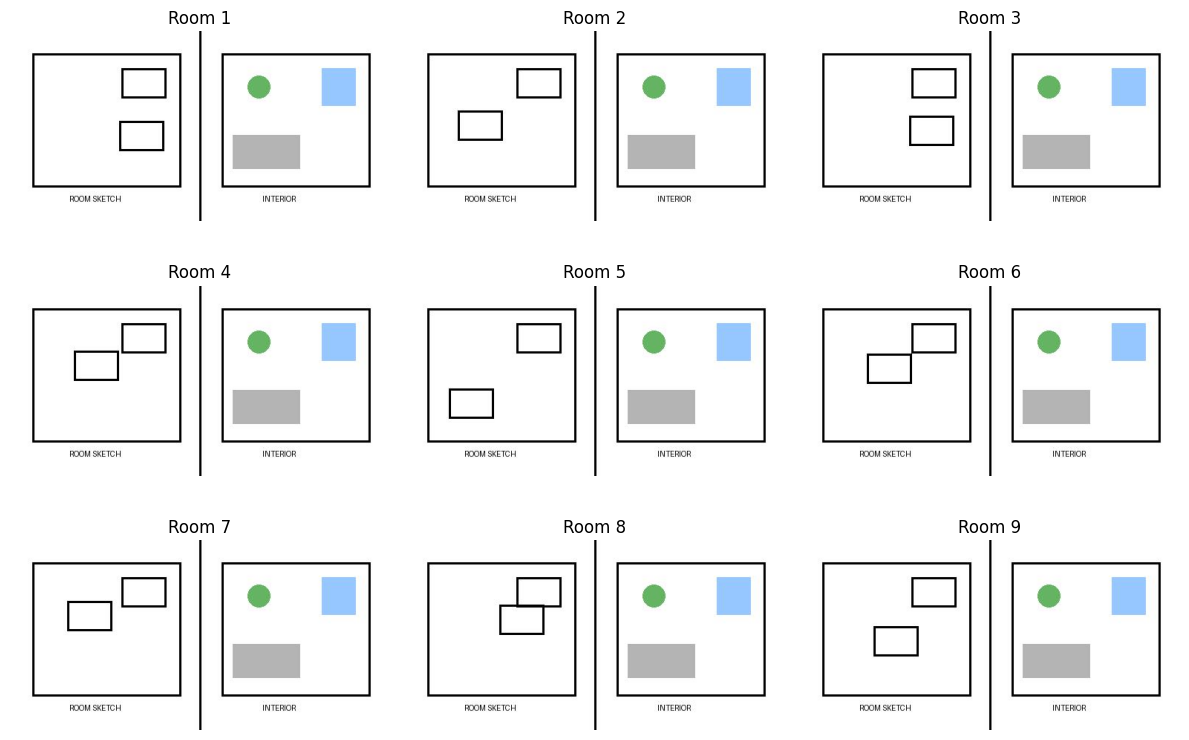

Total images: 50


In [ ]:
import glob
import matplotlib.pyplot as plt
from PIL import Image

images = glob.glob("/content/room_dataset/train/*.jpg")

plt.figure(figsize=(12, 8))

for i in range(9):
    img = Image.open(images[i])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Room {i + 1}")

plt.tight_layout()
plt.show()

print("Total images:", len(images))

In [ ]:
import tensorflow as tf
import glob

room_images = glob.glob(
    "/content/room_dataset/train/*.jpg"
)

IMG_SIZE = 256
BATCH_SIZE = 1

def load_room_image(file_path):

    image = tf.io.read_file(file_path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    # Resize
    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    # Normalize to -1 to 1
    image = (tf.cast(image, tf.float32) / 127.5) - 1

    # Split into sketch and interior
    width = tf.shape(image)[1]

    input_image = image[:, :width // 2, :]
    target_image = image[:, width // 2:, :]

    return input_image, target_image


room_dataset = tf.data.Dataset.from_tensor_slices(
    room_images
)

room_dataset = room_dataset.map(
    load_room_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

room_dataset = room_dataset.batch(BATCH_SIZE)

print("Room dataset loaded! ✅")

Room dataset loaded! ✅


In [ ]:
for input_image, target_image in room_dataset.take(1):

    print("Input shape:", input_image.shape)
    print("Target shape:", target_image.shape)

Input shape: (1, 256, 128, 3)
Target shape: (1, 256, 128, 3)


In [ ]:
for input_image, target_image in room_dataset.take(1):

    print("Input:", input_image.shape)
    print("Target:", target_image.shape)

    generated_image = generator(
        input_image,
        training=False
    )

    print("Generated:", generated_image.shape)

Input: (1, 256, 128, 3)
Target: (1, 256, 128, 3)
Generated: (1, 256, 128, 3)


In [ ]:
EPOCHS = 2

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    gen_loss_total = 0.0
    disc_loss_total = 0.0
    batches = 0

    for input_image, target_image in room_dataset:

        gen_loss, disc_loss = train_step(
            input_image,
            target_image
        )

        gen_loss_total += float(gen_loss)
        disc_loss_total += float(disc_loss)
        batches += 1

    print(
        f"Generator Loss: {gen_loss_total / batches:.4f}"
    )

    print(
        f"Discriminator Loss: {disc_loss_total / batches:.4f}"
    )

print("\nRoom training completed! ✅")


Epoch 1/2
Generator Loss: 57.3022
Discriminator Loss: 0.0898

Epoch 2/2
Generator Loss: 26.9954
Discriminator Loss: 0.0540

Room training completed! ✅


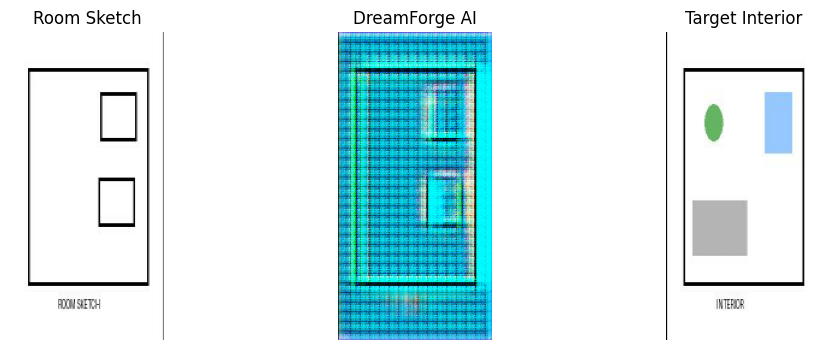

In [ ]:
import matplotlib.pyplot as plt

for input_image, target_image in room_dataset.take(1):

    generated_image = generator(
        input_image,
        training=False
    )

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow((input_image[0] + 1) / 2)
    plt.title("Room Sketch")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow((generated_image[0] + 1) / 2)
    plt.title("DreamForge AI")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow((target_image[0] + 1) / 2)
    plt.title("Target Interior")
    plt.axis("off")

    plt.show()

In [ ]:
generator.save("/content/dreamforge_room_generator.keras")

print("DreamForge room model saved! ✅")

DreamForge room model saved! ✅


In [ ]:
import os

print(
    os.path.exists(
        "/content/dreamforge_room_generator.keras"
    )
)

True


In [ ]:
from google.colab import files

files.download(
    "/content/dreamforge_room_generator.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>